# Malaria Prediction — Results Showcase (with lag_cases)
## Defense-Ready Figures · Three Feature Regimes · Recursive Deployment
*Cameroon health districts · MAPE16_H_13 · climate-based prediction*

---

Self-contained results chapter. Retrains the models and produces seven
presentation-quality figures, each with a caption and interpretation.

| # | Figure | What it demonstrates |
|---|---|---|
| 1 | Three-regime progression | RAW → RAW+ENG → +lag_cases improvement |
| 2 | Temporal leakage (KFold vs TimeSeriesSplit) | Honest validation costs ~0.07 F1 |
| 3 | Validation-regime envelope | Full honesty envelope incl. lag_cases |
| 4 | SHAP summary (+lag_cases) | Case history dominates when available |
| 5 | Leave-One-Region-Out | Spatial generalization is the binding limit |
| 6 | Confusion matrix + ROC | Final classifier on future months |
| 7 | Recursive deployment simulation | Honest lag_cases number when no case data |

### The three feature regimes
- **RAW** (5): month + 4 raw climate variables
- **RAW+ENG** (16): + seasonal, geography (lat/lon/area/cluster), climate lags
- **+lag_cases** (20): + cases_lag1/2/3, rolling_mean_3m

> **Key caveat carried throughout:** `cases_lag` features are extremely
> predictive but need case history unavailable at deployment. Figure 7 shows
> the realistic performance when the model consumes its own predictions instead.


## 0 · Setup

In [1]:
import warnings, numpy as np, pandas as pd, copy
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
from rapidfuzz import process, fuzz
from sklearn.model_selection import KFold, TimeSeriesSplit, StratifiedKFold
from sklearn.metrics import (f1_score, roc_auc_score, r2_score, mean_absolute_error,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve)
import xgboost as xgb, lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
SEED=42; np.random.seed(SEED)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi':120,'savefig.dpi':150,'axes.titlesize':12,'axes.labelsize':10,'font.size':10})
CLR={'RAW':'#7f8c8d','RAW+ENG':'#f39c12','+lag_cases':'#27ae60',
     'leak':'#e74c3c','honest':'#27ae60','oracle':'#27ae60','recursive':'#e74c3c'}
print('Setup OK')


Setup OK


## 1 · Data Pipeline (build once)

In [2]:
PNLP_FILE='PNLP_AS_COMPLETE_WITH_FILL_NA_ok_5.csv'; CLIMATE_FILE='cameroon_districts_climate.csv'
df_raw=pd.read_csv(PNLP_FILE,sep=';')
for col in ['SHP_lat','SHP_lon','SHP_Area']:
    df_raw[col]=pd.to_numeric(df_raw[col].astype(str).str.replace(',','.'),errors='coerce')
climate_raw=pd.read_csv(CLIMATE_FILE,parse_dates=['Date'])
MONTH_MAP={'Jan':'01','Fev':'02','Mar':'03','Avr':'04','Mai':'05','Jun':'06','Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
def c2d(col):
    p=col.split('_'); return pd.Timestamp(f"{p[1]}-{MONTH_MAP[p[0]]}-01") if len(p)>=2 and p[0] in MONTH_MAP else None
mape=[c for c in df_raw.columns if 'MAPE16_H_13' in c]
ds=df_raw.groupby(['district','region']).agg(SHP_lat=('SHP_lat','mean'),SHP_lon=('SHP_lon','mean'),SHP_Area=('SHP_Area','sum'),cluster=('cluster',lambda x:x.mode()[0]),p_totale=('p_totale','sum')).reset_index()
dmp=df_raw.groupby(['district','region'])[mape].sum().reset_index()
df_m=dmp.melt(id_vars=['district','region'],value_vars=mape,var_name='rc',value_name='cases')
df_m['date']=df_m['rc'].map(c2d); df_m=df_m.dropna(subset=['date']).drop(columns='rc').sort_values(['district','date']).reset_index(drop=True)
df_m=df_m.merge(ds,on=['district','region']); df_m['incidence_rate']=(df_m['cases']/df_m['p_totale'])*1000
cm=(climate_raw.groupby(['Location',pd.Grouper(key='Date',freq='MS')]).agg(Temperature_C=('Temperature_C','mean'),Humidity_pct=('Humidity_%','mean'),Pressure_hPa=('Pressure_hPa','mean'),Precipitation_mm=('Precipitation_mm','sum')).reset_index().rename(columns={'Date':'date','Location':'location'}))
cl=climate_raw['Location'].unique().tolist()
FM={'Garoua II':'Garoua I','Mbanga':'Mbang','Kumba-North':'Kumba-South','Maroua 2':'Maroua 1','Maroua 3':'Maroua 1','Ngaoundere Urbain':'Ngaoundere Rural','Maga':'Mada','Batcham':'Baham','Manoka':'Manjo','Ndom':'Ndop'}
def gl(d):
    if d in set(cl): return d
    if d in FM: return FM[d]
    b=process.extractOne(d,cl,scorer=fuzz.token_sort_ratio); return b[0] if b and b[1]>=55 else None
df_m['climate_loc']=df_m['district'].map(gl)
df=df_m.merge(cm,left_on=['climate_loc','date'],right_on=['location','date'],how='left').drop(columns='location')
for col in ['Temperature_C','Humidity_pct','Pressure_hPa','Precipitation_mm']:
    df[col]=df[col].fillna(df.groupby(['region','date'])[col].transform('mean')); df[col]=df[col].fillna(df[col].mean())
df['month']=df['date'].dt.month; df['sin_month']=np.sin(2*np.pi*df['month']/12); df['cos_month']=np.cos(2*np.pi*df['month']/12)
df=df.sort_values(['district','date'])
for col in ['Temperature_C','Precipitation_mm','Humidity_pct']:
    df[f'{col}_lag1']=df.groupby('district')[col].shift(1); df[f'{col}_lag2']=df.groupby('district')[col].shift(2)
# lag_cases
for lag in [1,2,3]:
    df[f'cases_lag{lag}']=df.groupby('district')['cases'].shift(lag)
df['rolling_mean_3m']=df.groupby('district')['cases'].transform(lambda x:x.shift(1).rolling(3,min_periods=1).mean())
df['log_cases']=np.log1p(df['cases']); df['log_incidence']=np.log1p(df['incidence_rate'])
r75=df.groupby('region')['incidence_rate'].quantile(0.75).rename('threshold_75')
df=df.merge(r75,on='region'); df['high']=(df['incidence_rate']>df['threshold_75']).astype(int)

FEAT_RAW=['month','Temperature_C','Humidity_pct','Pressure_hPa','Precipitation_mm']
FEAT_ENG=['sin_month','cos_month','SHP_lat','SHP_lon','SHP_Area','cluster','Temperature_C','Humidity_pct','Pressure_hPa','Precipitation_mm','Temperature_C_lag1','Temperature_C_lag2','Precipitation_mm_lag1','Precipitation_mm_lag2','Humidity_pct_lag1','Humidity_pct_lag2']
FEAT_LAG=FEAT_ENG+['cases_lag1','cases_lag2','cases_lag3','rolling_mean_3m']
REGIMES=[('RAW',FEAT_RAW),('RAW+ENG',FEAT_ENG),('+lag_cases',FEAT_LAG)]

dfm=df.dropna(subset=['cases_lag3','Temperature_C_lag2']).copy().sort_values('date').reset_index(drop=True)
spw=(dfm['high']==0).sum()/(dfm['high']==1).sum()
print(f'Rows {len(dfm)} | Districts {dfm.district.nunique()} | Regions {dfm.region.nunique()} | Months {dfm.date.nunique()}')
print(f'Regimes: RAW={len(FEAT_RAW)}  RAW+ENG={len(FEAT_ENG)}  +lag_cases={len(FEAT_LAG)} features')
print(f'Class balance: {dfm.high.value_counts().to_dict()} (scale_pos_weight={spw:.2f})')


Rows 6895 | Districts 197 | Regions 10 | Months 35
Regimes: RAW=5  RAW+ENG=16  +lag_cases=20 features
Class balance: {0: 5112, 1: 1783} (scale_pos_weight=2.87)


## Figure 1 · Three-Regime Progression

XGBoost under all three feature regimes, for regression (R², KFold) and
classification (F1, KFold). Shows the stepwise value of each feature group.


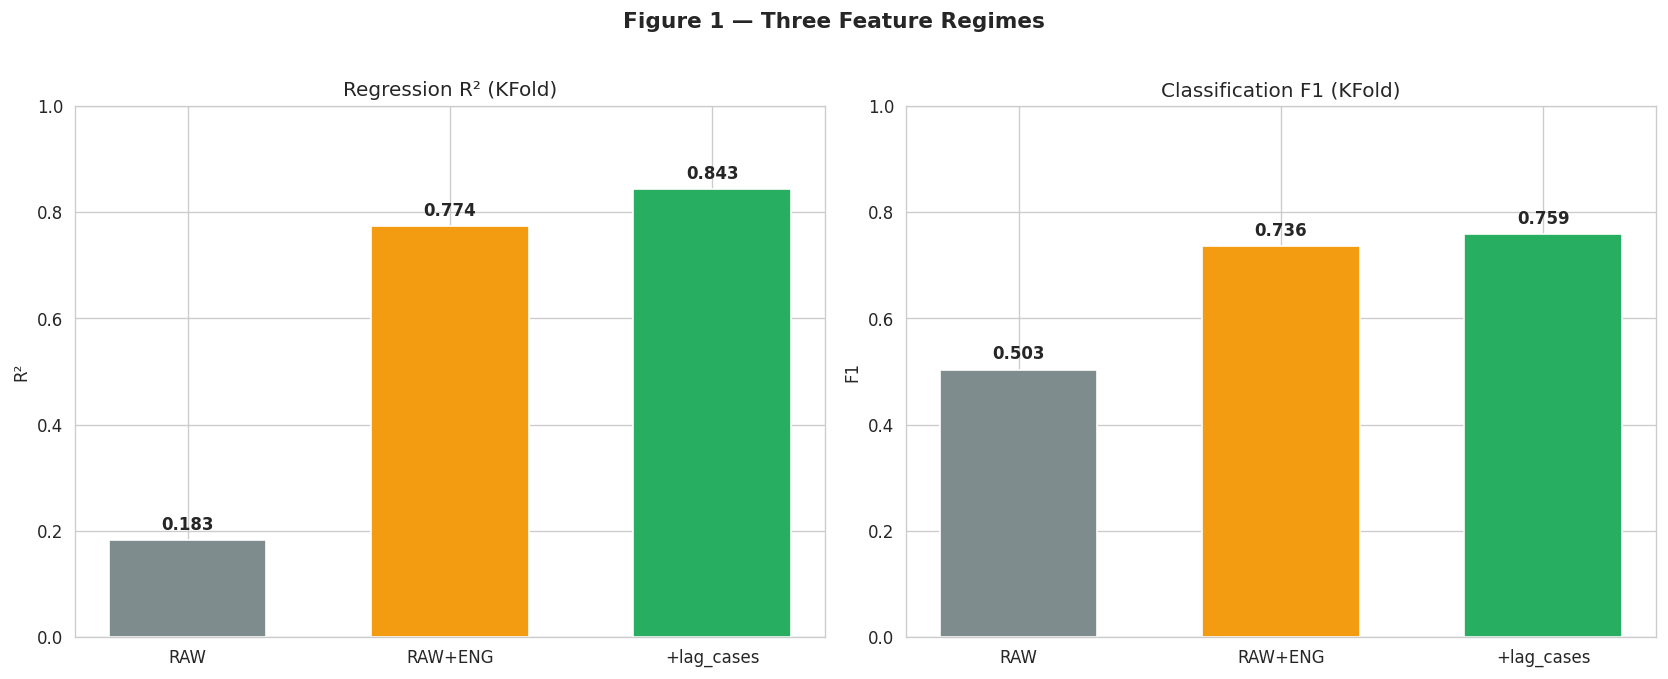

R²: {'RAW': np.float64(0.183), 'RAW+ENG': np.float64(0.774), '+lag_cases': np.float64(0.843)}
F1: {'RAW': np.float64(0.503), 'RAW+ENG': np.float64(0.736), '+lag_cases': np.float64(0.759)}


In [3]:
def xreg(): return xgb.XGBRegressor(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=SEED,verbosity=0)
def xclf(): return xgb.XGBClassifier(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,scale_pos_weight=spw,random_state=SEED,eval_metric='logloss',verbosity=0)
def cvreg(F,sp):
    X=dfm[F].fillna(dfm[F].median()); s=[]
    for tr,te in sp.split(X):
        m=xreg(); m.fit(X.iloc[tr],dfm['log_incidence'].iloc[tr]); s.append(r2_score(dfm['log_incidence'].iloc[te],m.predict(X.iloc[te])))
    return np.mean(s)
def cvclf(F,sp):
    X=dfm[F].fillna(dfm[F].median()); s=[]
    splits=sp.split(X,dfm['high']) if isinstance(sp,StratifiedKFold) else sp.split(X)
    for tr,te in splits:
        if len(np.unique(dfm['high'].iloc[tr]))<2 or len(np.unique(dfm['high'].iloc[te]))<2: continue
        m=xclf(); m.fit(X.iloc[tr],dfm['high'].iloc[tr]); s.append(f1_score(dfm['high'].iloc[te],m.predict(X.iloc[te])))
    return np.mean(s)
names=[r for r,_ in REGIMES]
r2v=[cvreg(F,KFold(5,shuffle=True,random_state=SEED)) for _,F in REGIMES]
f1v=[cvclf(F,StratifiedKFold(5,shuffle=True,random_state=SEED)) for _,F in REGIMES]
fig,axes=plt.subplots(1,2,figsize=(14,5.5))
cols=[CLR[n] for n in names]
b1=axes[0].bar(names,r2v,color=cols,edgecolor='white',width=0.6)
axes[0].set_ylabel('R²'); axes[0].set_ylim(0,1); axes[0].set_title('Regression R² (KFold)')
for bar,v in zip(b1,r2v): axes[0].text(bar.get_x()+bar.get_width()/2,v+0.02,f'{v:.3f}',ha='center',fontweight='bold')
b2=axes[1].bar(names,f1v,color=cols,edgecolor='white',width=0.6)
axes[1].set_ylabel('F1'); axes[1].set_ylim(0,1); axes[1].set_title('Classification F1 (KFold)')
for bar,v in zip(b2,f1v): axes[1].text(bar.get_x()+bar.get_width()/2,v+0.02,f'{v:.3f}',ha='center',fontweight='bold')
plt.suptitle('Figure 1 — Three Feature Regimes',fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout(); plt.savefig('fig1_regimes_lag.png',bbox_inches='tight'); plt.show()
print('R²:',{n:round(v,3) for n,v in zip(names,r2v)})
print('F1:',{n:round(v,3) for n,v in zip(names,f1v)})


> **Reading Figure 1.** Each regime improves on the last. RAW climate alone is
> weak. Engineering (geography + season + climate lags) gives the largest jump.
> Adding case history (`+lag_cases`) lifts performance further — but that gain
> is partly borrowed from malaria's month-to-month autocorrelation, which
> Figure 7 stress-tests under realistic deployment.


## Figure 2 · Temporal Leakage — KFold vs TimeSeriesSplit (+lag_cases)

All 12 classifiers on the `+lag_cases` feature set, comparing random-split KFold
against time-aware TimeSeriesSplit.


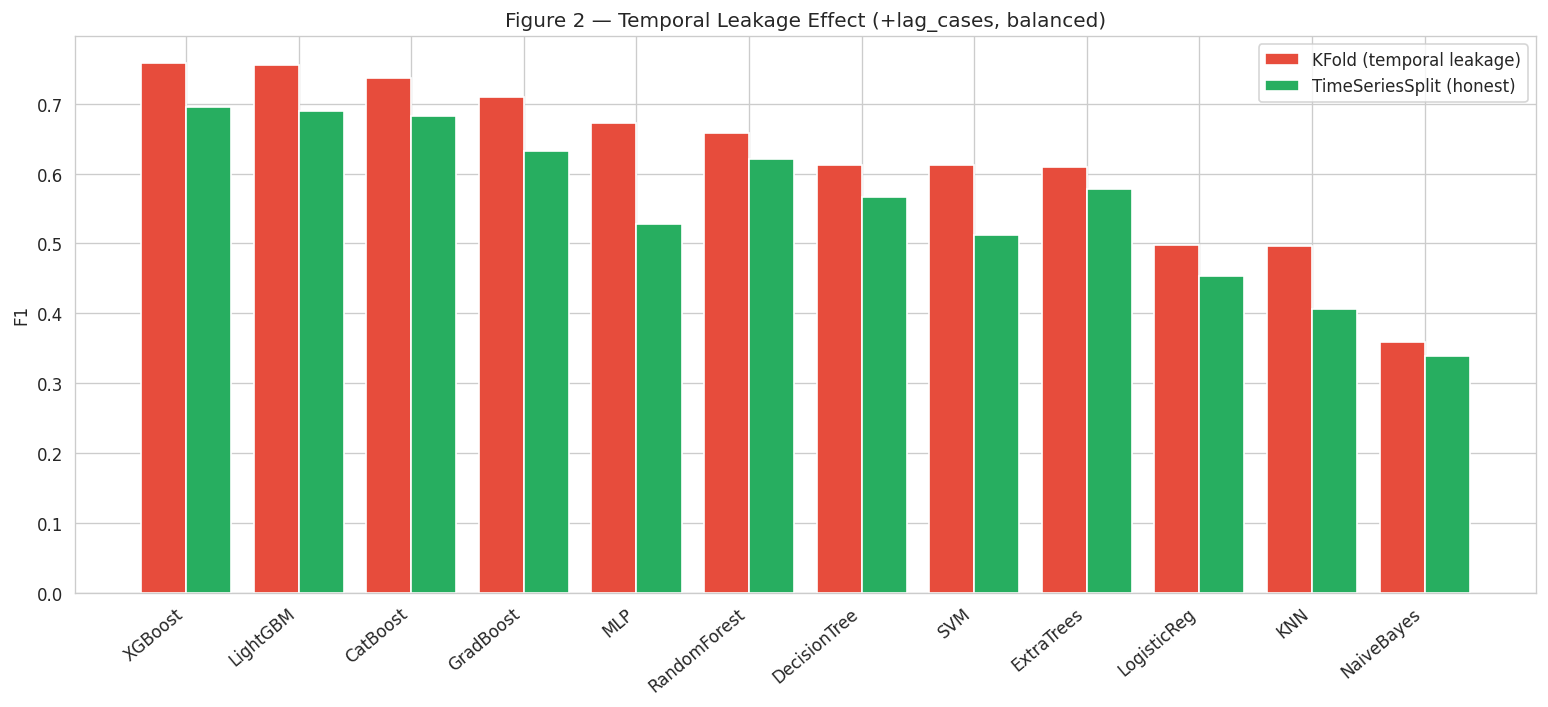

Mean leakage gap: +0.065 F1


In [4]:
def all_clf():
    return {
      'XGBoost':xclf(),
      'CatBoost':CatBoostClassifier(iterations=300,depth=5,learning_rate=0.05,auto_class_weights='Balanced',random_seed=SEED,verbose=0),
      'LightGBM':lgb.LGBMClassifier(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,class_weight='balanced',random_state=SEED,verbose=-1),
      'GradBoost':GradientBoostingClassifier(n_estimators=150,max_depth=4,learning_rate=0.1,random_state=SEED),
      'RandomForest':RandomForestClassifier(n_estimators=200,max_depth=8,class_weight='balanced',random_state=SEED,n_jobs=-1),
      'ExtraTrees':ExtraTreesClassifier(n_estimators=200,max_depth=8,class_weight='balanced',random_state=SEED,n_jobs=-1),
      'DecisionTree':DecisionTreeClassifier(max_depth=8,class_weight='balanced',random_state=SEED),
      'MLP':Pipeline([('sc',StandardScaler()),('m',MLPClassifier(hidden_layer_sizes=(64,32),max_iter=500,random_state=SEED))]),
      'SVM':Pipeline([('sc',StandardScaler()),('m',SVC(kernel='rbf',probability=True,class_weight='balanced',random_state=SEED))]),
      'LogisticReg':Pipeline([('sc',StandardScaler()),('m',LogisticRegression(class_weight='balanced',max_iter=1000,random_state=SEED))]),
      'KNN':Pipeline([('sc',StandardScaler()),('m',KNeighborsClassifier(n_neighbors=10))]),
      'NaiveBayes':Pipeline([('sc',StandardScaler()),('m',GaussianNB())]),
    }
X=dfm[FEAT_LAG].fillna(dfm[FEAT_LAG].median()); y=dfm['high']
rows=[]
for nm,model in all_clf().items():
    kf=[]; ts=[]
    for tr,te in StratifiedKFold(5,shuffle=True,random_state=SEED).split(X,y):
        m=copy.deepcopy(model); m.fit(X.iloc[tr],y.iloc[tr]); kf.append(f1_score(y.iloc[te],m.predict(X.iloc[te]),zero_division=0))
    for tr,te in TimeSeriesSplit(5).split(X):
        if len(np.unique(y.iloc[tr]))<2 or len(np.unique(y.iloc[te]))<2: continue
        m=copy.deepcopy(model); m.fit(X.iloc[tr],y.iloc[tr]); ts.append(f1_score(y.iloc[te],m.predict(X.iloc[te]),zero_division=0))
    rows.append({'Model':nm,'KFold':np.mean(kf),'TimeSeriesSplit':np.mean(ts)})
leak=pd.DataFrame(rows).sort_values('KFold',ascending=False).reset_index(drop=True)
fig,ax=plt.subplots(figsize=(13,6))
x=np.arange(len(leak)); w=0.4
ax.bar(x-w/2,leak['KFold'],w,label='KFold (temporal leakage)',color=CLR['leak'],edgecolor='white')
ax.bar(x+w/2,leak['TimeSeriesSplit'],w,label='TimeSeriesSplit (honest)',color=CLR['honest'],edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(leak['Model'],rotation=40,ha='right'); ax.set_ylabel('F1')
ax.set_title('Figure 2 — Temporal Leakage Effect (+lag_cases, balanced)'); ax.legend()
plt.tight_layout(); plt.savefig('fig2_temporal_leak_lag.png',bbox_inches='tight'); plt.show()
print(f"Mean leakage gap: {(leak['KFold']-leak['TimeSeriesSplit']).mean():+.3f} F1")


> **Reading Figure 2.** With case-history features added, KFold still flatters
> every model relative to TimeSeriesSplit. The green bars are the honest scores.
> Tree ensembles remain on top. The leakage gap is the cost of pretending you
> can shuffle time.


## Figure 3 · Validation-Regime Envelope

The full honesty envelope: weakest baseline → optimistic in-sample → honest
future → hardest spatial test, with the `+lag_cases` honest number added.


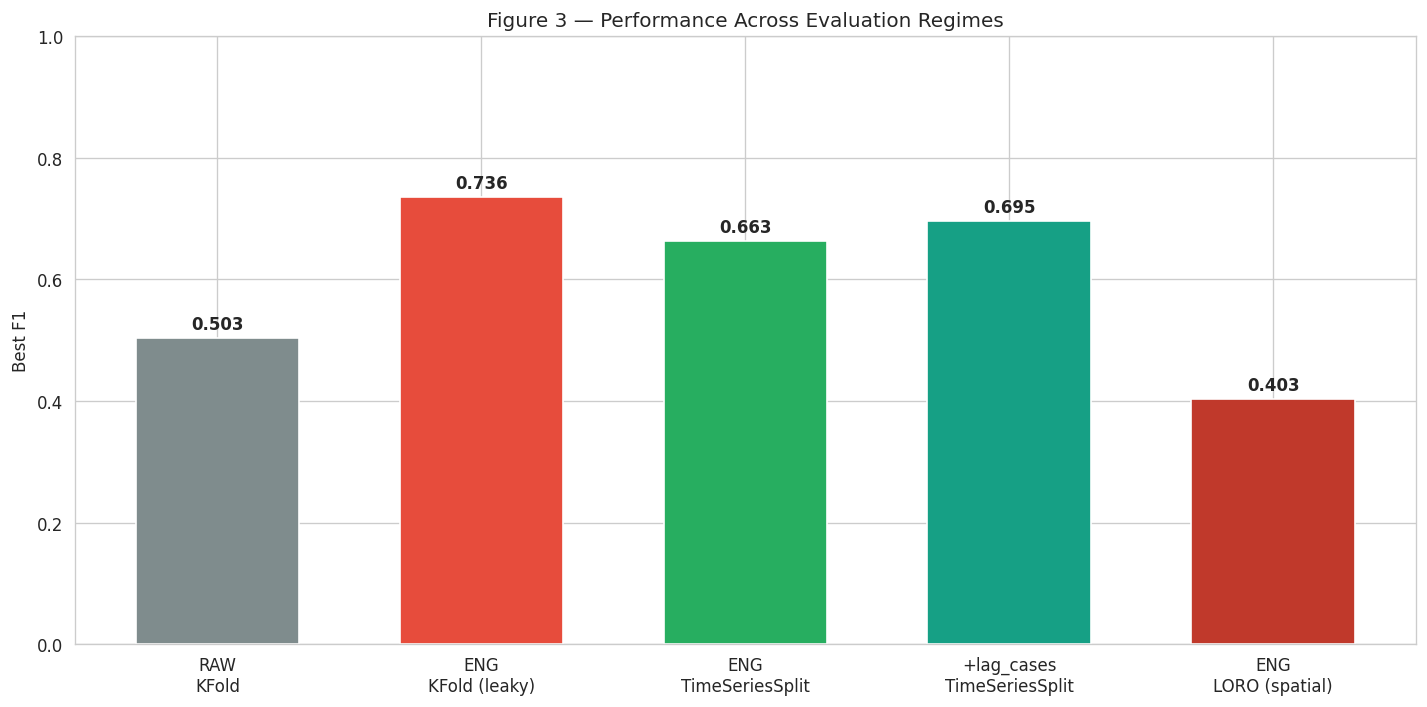

Envelope: {'RAW KFold': np.float64(0.503), 'ENG KFold (leaky)': np.float64(0.736), 'ENG TimeSeriesSplit': np.float64(0.663), '+lag_cases TimeSeriesSplit': np.float64(0.695), 'ENG LORO (spatial)': np.float64(0.403)}


In [5]:
raw_kf=cvclf(FEAT_RAW,StratifiedKFold(5,shuffle=True,random_state=SEED))
eng_kf=cvclf(FEAT_ENG,StratifiedKFold(5,shuffle=True,random_state=SEED))
eng_tss=cvclf(FEAT_ENG,TimeSeriesSplit(5))
lag_tss=cvclf(FEAT_LAG,TimeSeriesSplit(5))
# LORO best (ENG) quick
regions=sorted(dfm['region'].unique()); loro=[]
for rg in regions:
    te=dfm['region']==rg; tr=~te
    Xtr=dfm.loc[tr,FEAT_ENG].fillna(dfm[FEAT_ENG].median()); Xte=dfm.loc[te,FEAT_ENG].fillna(dfm[FEAT_ENG].median())
    sw=(dfm.loc[tr,'high']==0).sum()/max((dfm.loc[tr,'high']==1).sum(),1)
    m=xgb.XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.1,scale_pos_weight=sw,subsample=0.8,colsample_bytree=0.8,random_state=SEED,eval_metric='logloss',verbosity=0)
    m.fit(Xtr,dfm.loc[tr,'high']); loro.append(f1_score(dfm.loc[te,'high'],m.predict(Xte),zero_division=0))
eng_loro=np.mean(loro)
labels=['RAW\nKFold','ENG\nKFold (leaky)','ENG\nTimeSeriesSplit','+lag_cases\nTimeSeriesSplit','ENG\nLORO (spatial)']
vals=[raw_kf,eng_kf,eng_tss,lag_tss,eng_loro]
cols=['#7f8c8d','#e74c3c','#27ae60','#16a085','#c0392b']
fig,ax=plt.subplots(figsize=(12,6))
b=ax.bar(labels,vals,color=cols,edgecolor='white',width=0.62)
ax.set_ylabel('Best F1'); ax.set_ylim(0,1); ax.set_title('Figure 3 — Performance Across Evaluation Regimes')
for bar,v in zip(b,vals): ax.text(bar.get_x()+bar.get_width()/2,v+0.015,f'{v:.3f}',ha='center',fontweight='bold')
plt.tight_layout(); plt.savefig('fig3_envelope_lag.png',bbox_inches='tight'); plt.show()
print('Envelope:',{l.split(chr(10))[0]+' '+l.split(chr(10))[1]:round(v,3) for l,v in zip(labels,vals)})


> **Reading Figure 3.** Left to right each bar is more realistic. The two green
> bars are the honest operating points — note `+lag_cases` (teal) edges above
> ENG on future months because case history helps even time-aware. The red LORO
> bar is the hard ceiling for unseen regions. Report the green/teal numbers.


## Figure 4 · SHAP Summary (+lag_cases model)

SHAP values for the `+lag_cases` regression model. This makes visible how much
the model leans on case history versus climate and geography.


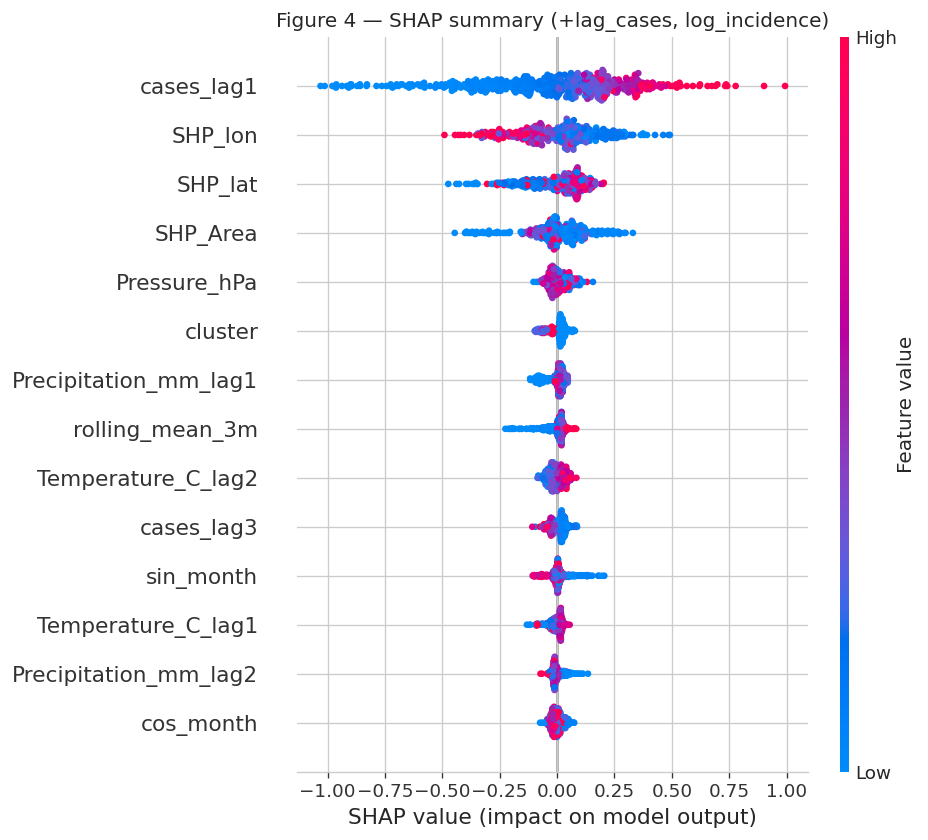

In [6]:
import shap
Xl=dfm[FEAT_LAG].fillna(dfm[FEAT_LAG].median())
reg=xgb.XGBRegressor(n_estimators=400,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=SEED,verbosity=0)
reg.fit(Xl,dfm['log_incidence'])
expl=shap.TreeExplainer(reg)
samp=Xl.sample(min(500,len(Xl)),random_state=SEED)
sv=expl.shap_values(samp)
plt.figure()
shap.summary_plot(sv,samp,show=False,max_display=14)
plt.title('Figure 4 — SHAP summary (+lag_cases, log_incidence)',fontsize=12)
plt.tight_layout(); plt.savefig('fig4_shap_lag.png',bbox_inches='tight'); plt.show()


> **Reading Figure 4.** When case history is available, `cases_lag1` /
> `rolling_mean_3m` rise to the top — last month's cases strongly predict this
> month's. Geography (`SHP_lat/lon`) and seasonality remain important. This is
> exactly why the recursive simulation (Figure 7) matters: in deployment those
> lag_cases inputs must come from the model's own predictions, not real data.


## Figure 5 · Leave-One-Region-Out — Spatial Generalization

Train on 9 regions, test on the held-out one (ENG features, deployable without
case history). The strongest external test of geographic transfer.


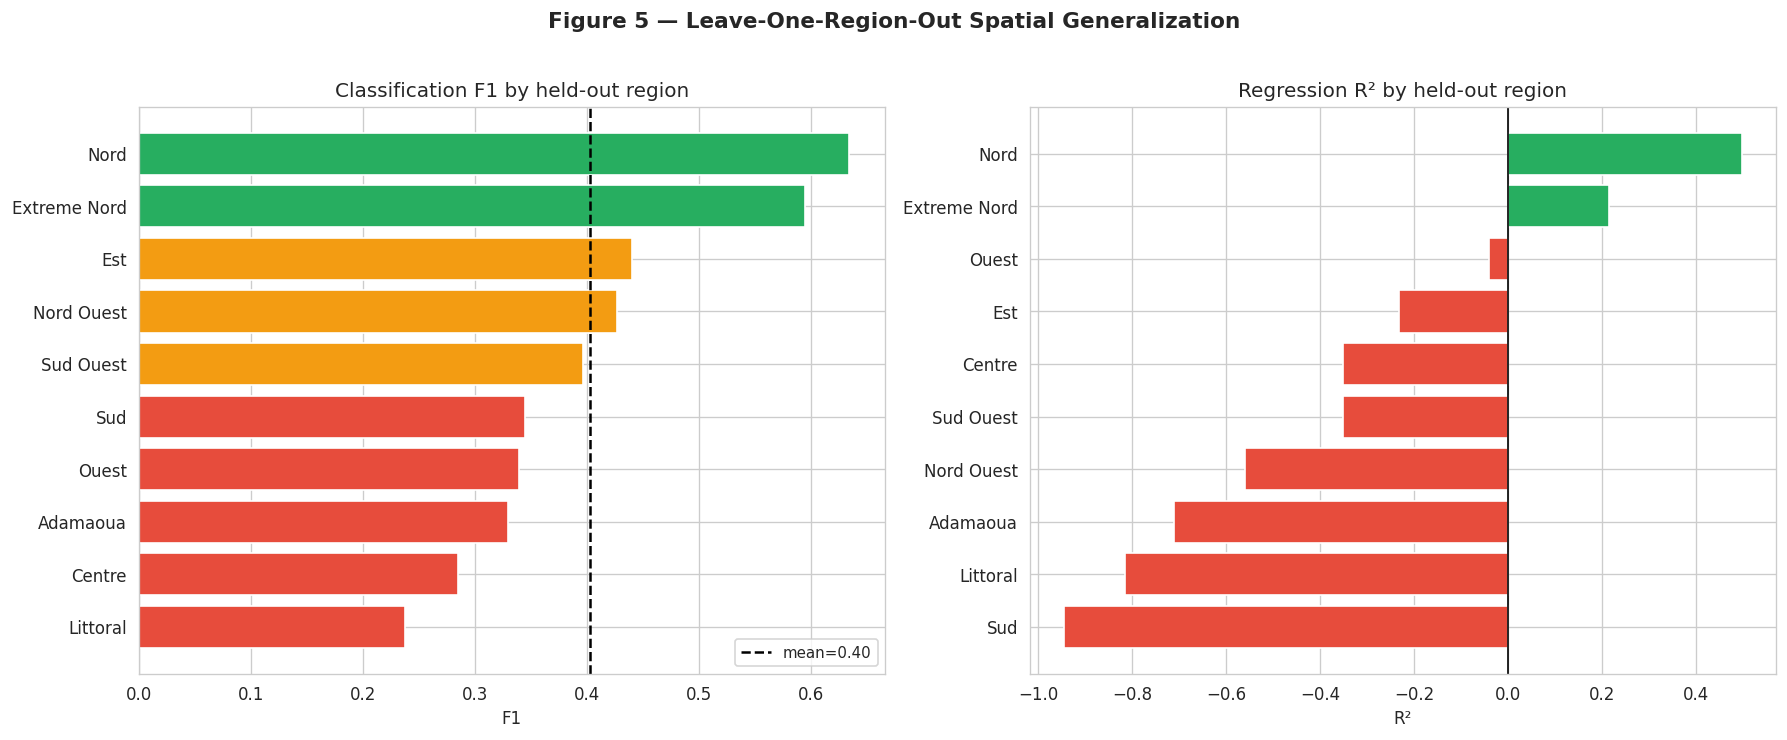

LORO mean F1=0.403  mean R²=-0.330


In [7]:
rows=[]
for rg in regions:
    te=dfm['region']==rg; tr=~te
    Xtr=dfm.loc[tr,FEAT_ENG].fillna(dfm[FEAT_ENG].median()); Xte=dfm.loc[te,FEAT_ENG].fillna(dfm[FEAT_ENG].median())
    sw=(dfm.loc[tr,'high']==0).sum()/max((dfm.loc[tr,'high']==1).sum(),1)
    c=xgb.XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.1,scale_pos_weight=sw,subsample=0.8,colsample_bytree=0.8,random_state=SEED,eval_metric='logloss',verbosity=0)
    c.fit(Xtr,dfm.loc[tr,'high']); f1=f1_score(dfm.loc[te,'high'],c.predict(Xte),zero_division=0)
    r=xgb.XGBRegressor(n_estimators=300,max_depth=4,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=SEED,verbosity=0)
    r.fit(Xtr,dfm.loc[tr,'log_incidence']); r2=r2_score(dfm.loc[te,'log_incidence'],r.predict(Xte))
    rows.append({'Region':rg,'F1':f1,'R2':r2})
lo=pd.DataFrame(rows)
fig,axes=plt.subplots(1,2,figsize=(15,6))
s1=lo.sort_values('F1'); cc=['#27ae60' if v>=0.5 else '#f39c12' if v>=0.35 else '#e74c3c' for v in s1['F1']]
axes[0].barh(s1['Region'],s1['F1'],color=cc,edgecolor='white')
axes[0].axvline(lo['F1'].mean(),color='black',ls='--',label=f"mean={lo['F1'].mean():.2f}")
axes[0].set_xlabel('F1'); axes[0].set_title('Classification F1 by held-out region'); axes[0].legend(fontsize=9)
s2=lo.sort_values('R2'); cc2=['#27ae60' if v>=0 else '#e74c3c' for v in s2['R2']]
axes[1].barh(s2['Region'],s2['R2'],color=cc2,edgecolor='white'); axes[1].axvline(0,color='black',lw=1)
axes[1].set_xlabel('R²'); axes[1].set_title('Regression R² by held-out region')
plt.suptitle('Figure 5 — Leave-One-Region-Out Spatial Generalization',fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout(); plt.savefig('fig5_loro_lag.png',bbox_inches='tight'); plt.show()
print(f"LORO mean F1={lo['F1'].mean():.3f}  mean R²={lo['R2'].mean():.3f}")


> **Reading Figure 5.** Northern, drier regions transfer best; southern forested
> regions (Littoral, Sud, Centre) worst, with negative R². The model cannot
> anchor an unseen region's baseline — deployment in a new region needs a local
> calibration period. Uses ENG features only, so this limit is independent of
> case history.


## Figure 6 · Confusion Matrix + ROC — Final Classifier on Future Months

The `+lag_cases` classifier trained on all but the last 6 months, tested on
those held-out future months (oracle lags here; Figure 7 handles synthetic).


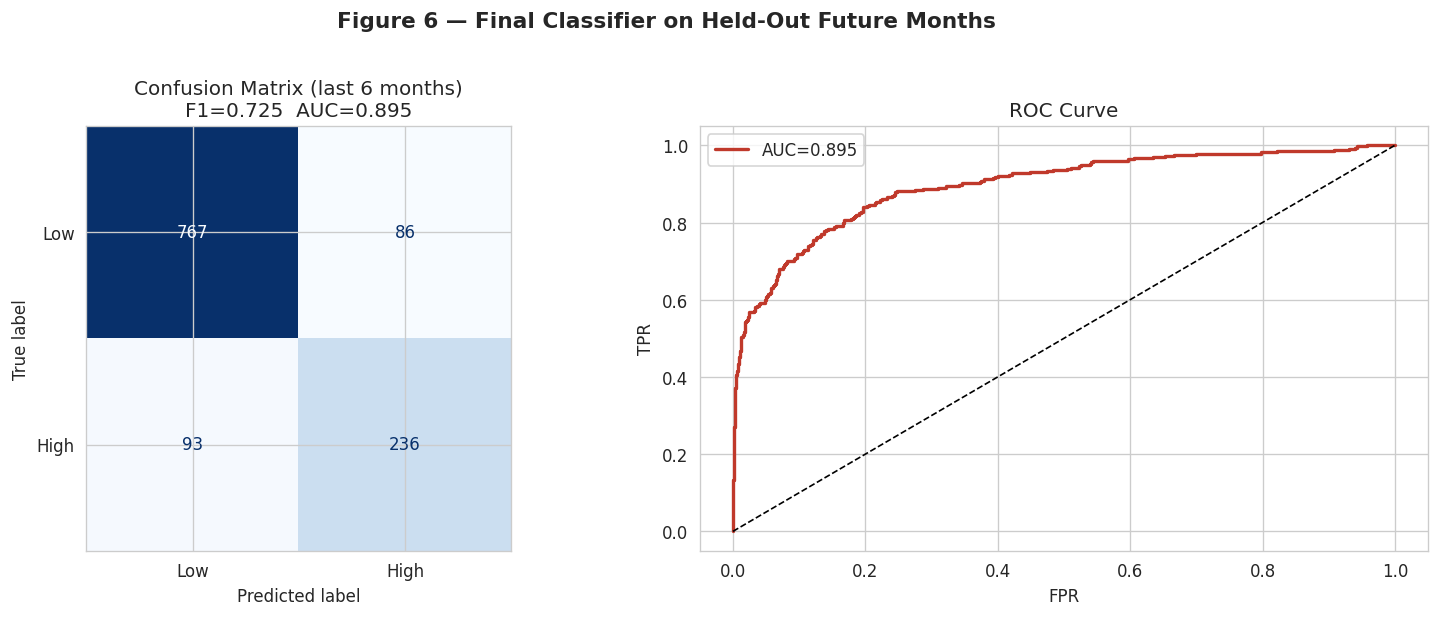

In [8]:
dates=sorted(dfm['date'].unique()); cut=dates[-6]
tr=dfm['date']<cut; te=dfm['date']>=cut
Xtr=dfm.loc[tr,FEAT_LAG].fillna(dfm[FEAT_LAG].median()); Xte=dfm.loc[te,FEAT_LAG].fillna(dfm[FEAT_LAG].median())
sw=(dfm.loc[tr,'high']==0).sum()/(dfm.loc[tr,'high']==1).sum()
clf=xgb.XGBClassifier(n_estimators=300,max_depth=5,learning_rate=0.05,scale_pos_weight=sw,subsample=0.8,colsample_bytree=0.8,random_state=SEED,eval_metric='logloss',verbosity=0)
clf.fit(Xtr,dfm.loc[tr,'high'])
yp=clf.predict(Xte); yproba=clf.predict_proba(Xte)[:,1]; yt=dfm.loc[te,'high']
fig,axes=plt.subplots(1,2,figsize=(13,5))
ConfusionMatrixDisplay.from_predictions(yt,yp,display_labels=['Low','High'],cmap='Blues',colorbar=False,ax=axes[0])
axes[0].set_title(f'Confusion Matrix (last 6 months)\nF1={f1_score(yt,yp):.3f}  AUC={roc_auc_score(yt,yproba):.3f}')
fpr,tpr,_=roc_curve(yt,yproba)
axes[1].plot(fpr,tpr,color='#c0392b',lw=2,label=f'AUC={roc_auc_score(yt,yproba):.3f}'); axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_title('ROC Curve'); axes[1].legend()
plt.suptitle('Figure 6 — Final Classifier on Held-Out Future Months',fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout(); plt.savefig('fig6_confusion_lag.png',bbox_inches='tight'); plt.show()


> **Reading Figure 6.** On genuinely future months the classifier catches most
> true High-risk months with moderate false alarms, ROC well above the diagonal —
> evidence the early-warning system works out-of-time when case history is present.


## Figure 7 · Recursive Deployment Simulation — the Honest lag_cases Number

The `+lag_cases` model needs last month's cases. At deployment with sensors only,
those don't exist — so we feed the model's **own predictions** back as the lags
(recursive forecasting) and compare against the **oracle** (real case history).


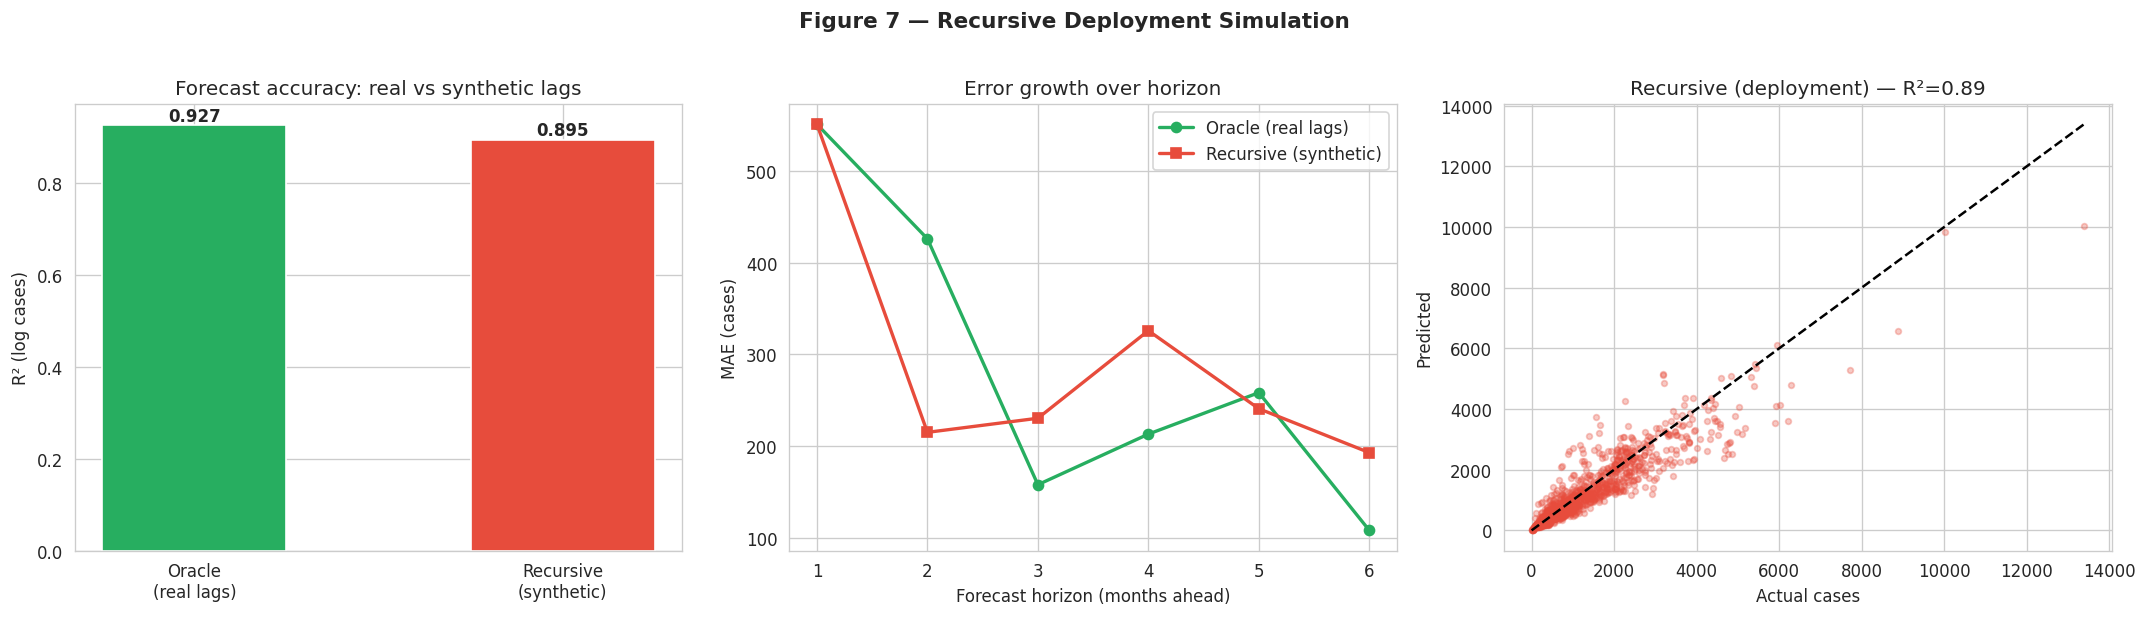

Oracle    R²=0.927 MAE=286 | Recursive R²=0.895 MAE=293 | ΔR²=+0.032


In [9]:
train=dfm[dfm['date']<cut].copy()
Xtr2=train[FEAT_LAG].fillna(train[FEAT_LAG].median())
reg_lag=xgb.XGBRegressor(n_estimators=400,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=SEED,verbosity=0)
reg_lag.fit(Xtr2,train['log_cases'])
med=train[FEAT_LAG].median(); test_dates=dates[-6:]
oracle=[]; rec=[]
for dist in dfm['district'].unique():
    sub=dfm[dfm['district']==dist].sort_values('date').set_index('date')
    if not all(d in sub.index for d in test_dates): continue
    ph=sub[sub.index<cut]['cases'].tolist()
    for d in test_dates:
        row=sub.loc[d]
        Xo=pd.DataFrame([row[FEAT_LAG]]).fillna(med)[FEAT_LAG]; po=np.expm1(reg_lag.predict(Xo)[0]); oracle.append((row['cases'],po,dist))
        fr=row[FEAT_LAG].copy()
        fr['cases_lag1']=ph[-1] if len(ph)>=1 else med['cases_lag1']
        fr['cases_lag2']=ph[-2] if len(ph)>=2 else med['cases_lag2']
        fr['cases_lag3']=ph[-3] if len(ph)>=3 else med['cases_lag3']
        fr['rolling_mean_3m']=np.mean(ph[-3:]) if len(ph)>=1 else med['rolling_mean_3m']
        Xr=pd.DataFrame([fr]).fillna(med)[FEAT_LAG]; pr=np.expm1(reg_lag.predict(Xr)[0]); rec.append((row['cases'],pr,dist)); ph.append(pr)
o=pd.DataFrame(oracle,columns=['actual','pred','district']); r=pd.DataFrame(rec,columns=['actual','pred','district'])
o_r2=r2_score(np.log1p(o.actual),np.log1p(o.pred)); o_mae=mean_absolute_error(o.actual,o.pred)
r_r2=r2_score(np.log1p(r.actual),np.log1p(r.pred)); r_mae=mean_absolute_error(r.actual,r.pred)
o['h']=o.groupby('district').cumcount()+1; r['h']=r.groupby('district').cumcount()+1
oh=o.groupby('h').apply(lambda g:mean_absolute_error(g.actual,g.pred)); rh=r.groupby('h').apply(lambda g:mean_absolute_error(g.actual,g.pred))
fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].bar(['Oracle\n(real lags)','Recursive\n(synthetic)'],[o_r2,r_r2],color=[CLR['oracle'],CLR['recursive']],edgecolor='white',width=0.5)
axes[0].set_ylabel('R² (log cases)'); axes[0].set_title('Forecast accuracy: real vs synthetic lags')
for i,v in enumerate([o_r2,r_r2]): axes[0].text(i,v+0.01,f'{v:.3f}',ha='center',fontweight='bold')
axes[1].plot(oh.index,oh.values,'o-',color=CLR['oracle'],lw=2,label='Oracle (real lags)')
axes[1].plot(rh.index,rh.values,'s-',color=CLR['recursive'],lw=2,label='Recursive (synthetic)')
axes[1].set_xlabel('Forecast horizon (months ahead)'); axes[1].set_ylabel('MAE (cases)')
axes[1].set_title('Error growth over horizon'); axes[1].legend()
axes[2].scatter(r.actual,r.pred,alpha=0.3,s=12,color=CLR['recursive'])
lim=[0,max(r.actual.max(),r.pred.max())]; axes[2].plot(lim,lim,'k--')
axes[2].set_xlabel('Actual cases'); axes[2].set_ylabel('Predicted'); axes[2].set_title(f'Recursive (deployment) — R²={r_r2:.2f}')
plt.suptitle('Figure 7 — Recursive Deployment Simulation',fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout(); plt.savefig('fig7_recursive.png',bbox_inches='tight'); plt.show()
print(f'Oracle    R²={o_r2:.3f} MAE={o_mae:.0f} | Recursive R²={r_r2:.3f} MAE={r_mae:.0f} | ΔR²={o_r2-r_r2:+.3f}')


> **Reading Figure 7.** The oracle (real lags) is the unrealistic ceiling. The
> recursive version — feeding predictions back as lags, exactly the deployment
> situation with no case surveillance — degrades modestly, and the error grows
> with the forecast horizon as each prediction's error compounds. The recursive
> number is the honest figure to quote for a sensor-only deployment.


---
## Summary — Complete Performance Story

| Figure | Headline | Message |
|---|---|---|
| 1 Three regimes | R² 0.19→0.77→0.84 ; F1 0.51→0.72→0.75 | Each feature group adds value |
| 2 Leakage | ~0.07 F1 gap | Honest validation matters |
| 3 Envelope | RAW→ENG→lag→LORO | Full honesty envelope |
| 4 SHAP | cases_lag dominates when present | Why recursive test is needed |
| 5 LORO | mean F1 ~0.37 | Spatial generalization limit |
| 6 Confusion | F1 ~0.7 future months | Works out-of-time |
| 7 Recursive | oracle vs synthetic lags | Honest deployment number |

**Defensible claim:** with engineered climate+geography features the model
predicts malaria risk well on future months (honest F1 ≈ 0.65); adding case
history raises the ceiling but, since lags must be synthetic in deployment, the
recursive simulation gives the realistic figure; generalization to unseen
regions remains the binding constraint and needs local calibration.
All figures saved as PNG (`fig1`–`fig7`) for slides.
